In [378]:

#import yfinance as yf
import numpy as np
import datetime
import pandas as pd

from saber import PyFolio as pf
from saber import utilities as ut
from saber import mailer as mail
from saber import metaLib as mtlib
from saber import metaData as mtd
from saber import riskEngine as risk
from saber import PcEngine as pe
from saber import implementationEngine as ie


mtw = mtlib.meta5_wrapper()

def volume_transform(volume):
    volume = volume.pct_change()
    vol_pointer = [1 if v>0.2 else np.nan for v in volume]
    vol_pointer = pd.Series(vol_pointer)
    vol = [1.5 if v==1 else 0.5 for v in vol_pointer]
    #print(vol_pointer.tail(60))
    volume = pd.Series(vol,index = volume.index)
    #volume = (volume/(abs(volume).sum()))*len(volume)
    return volume


def get_usdjpy_signal():
    dt_now = datetime.datetime.now()+datetime.timedelta(hours=3)
    yen = mtw.get_tick_data("USDJPY",periodicity='1h',timeframe=  24000,end_dt = dt_now)
    yen['volume'] = volume_transform(yen['tick_volume'])
    yen['sma1'] = yen['close'].rolling(window=1).mean()
    yen['sma24'] = yen['close'].rolling(window=24).mean()
    yen['vol'] = yen['close'].diff().rolling(5).std()
    yen['signal'] = np.where(yen['sma1'] > yen['sma24'], 1, -1)
    yen['signal'] = yen['signal']*yen['volume']
    return yen
    #return yen
    sig = yen.signal.iloc[-1]
    var_multiplier = yen.volume.iloc[-1]
    
    return float(sig),float(var_multiplier)


def get_usdjpy_pos(var_target = 250):
    sig,var_multiplier = get_usdjpy_signal()
    pos = ie.execution().get_default_zero_pos()
    pos['USDJPY'] = sig
    
    var = risk.riskMgr().get_pos_theoretical_var(pos)
    
    sig = (sig*var_target*var_multiplier)/var
    sig = round(sig/0.01)*0.01
    pos['USDJPY'] = sig
    
    return pos

In [379]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import yfinance as yf

from saber import metaLib as mtlib
from saber import PyFolio as pf
from saber import utilities as ut
from saber import mailer as mail

from saber import metaData as mtd
from saber import riskEngine as risk
from saber import PcEngine as pe
from saber import implementationEngine as ie
from saber import PyFolio as pyf
from saber import PerformanceAnalytics as pa
import os

import mt5plalib as plalb

mtw = mtlib.meta5_wrapper()#login = 7933713,pw = '1523@Rocket')
PerfA = pa.PA(mtw)
rkm = risk.riskMgr(mtw)
mtd.data(mtw).update_tick_data()
mtd.data(mtw).update_trade_sized_close()

VIX_F6  download failed
VIX_G6  download failed
VIX_J6  download failed
VIX_K6  download failed
VIX_M6  download failed
VIX_N6  download failed
VIX_Q6  download failed
VIX_U6  download failed
VIX_V6  download failed
VIX_X6  download failed
VIX_Z6  download failed
UST30Y_H6  download failed


In [380]:
dollyen_realized = PerfA.get_trade_hist()
dollayenrlsd = dollyen_realized[dollyen_realized['symbol'] == 'USDJPY']
dollayenrlsd

,ticket,order,date,date_msc,type,entry,magic,position_id,reason,volume,price,commission,swap,profit,fee,symbol,comment,external_id
2025-11-05,804899310,857455594,1762287830,1762287830487,0,0,123456,857455594,3,0.21,153.582,0.0,0.00,0.00,0.0,USDJPY,,3664404923
2025-11-05,805204796,857818533,1762334075,1762334075453,1,1,123456,857455594,3,0.01,153.540,0.0,0.11,-0.36,0.0,USDJPY,,3665434095
2025-11-05,805289960,857914944,1762344029,1762344029510,0,0,123456,857914944,3,0.01,153.699,0.0,0.00,0.00,0.0,USDJPY,,3665739464
2025-11-05,805303482,857929154,1762344935,1762344935165,1,1,123456,857455594,3,0.01,153.779,0.0,0.11,1.67,0.0,USDJPY,,3665791291
2025-11-05,805303488,857929160,1762344935,1762344935411,1,1,123456,857914944,3,0.01,153.779,0.0,0.00,0.68,0.0,USDJPY,,3665791304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-14,882926107,4381648927,1773417656,1773417656223,0,0,123456,4381648927,3,0.67,159.315,0.0,0.00,0.00,0.0,USDJPY,,3916997508
2026-03-14,882986218,4381715395,1773421292,1773421292717,1,1,123456,4381648927,3,0.67,159.121,0.0,0.00,-104.52,0.0,USDJPY,,3917196998
2026-03-14,882986225,4381715402,1773421292,1773421292980,1,0,123456,4381715402,3,0.23,159.120,0.0,0.00,0.00,0.0,USDJPY,,3917197015
2026-03-14,883065525,4381803082,1773424930,1773424930058,0,1,123456,4381715402,3,0.23,159.417,0.0,0.00,-54.90,0.0,USDJPY,,3917480670


In [381]:
def get_btcusd_signal():
    dt_now = datetime.datetime.now()+ datetime.timedelta(hours=2)
    yen = mtw.get_tick_data("BTCUSD",periodicity='1h',timeframe=  24000,end_dt = dt_now)
    yen['volume'] = volume_transform(yen['tick_volume'])
    yen['sma1'] = yen['close'].rolling(window=1).mean()
    yen['sma24'] = yen['close'].rolling(window=24).mean()
    yen['vol'] = yen['close'].diff().rolling(5).std()
    yen['signal'] = np.where(yen['sma1'] > yen['sma24'], 1, -1)
    yen['signal'] = yen['signal']*yen['volume']
    return yen
def get_btcusd_live():
    dt_now = datetime.datetime.now()+ datetime.timedelta(hours=2)
    yen = mtw.get_tick_data("BTCUSD",periodicity='1h',timeframe=  24000,end_dt = dt_now)
    yen['volume'] = volume_transform(yen['tick_volume'])
    yen['sma1'] = yen['close'].rolling(window=1).mean()
    yen['sma24'] = yen['close'].rolling(window=24).mean()
    yen['vol'] = yen['close'].diff().rolling(5).std()
    yen['signal'] = np.where(yen['sma1'] > yen['sma24'], 1, -1)
    yen['signal'] = yen['signal']*yen['volume']
    return yen
get_btcusd_signal()

,open,high,low,close,tick_volume,spread,real_volume,asset,volume,sma1,sma24,vol,signal
Date,,,,,,,,,,,,,
2023-06-15 16:00:00,24895.50,25046.25,24867.74,24993.64,8833,109,0,BTCUSD,0.5,24993.64,NaN,NaN,-0.5
2023-06-15 17:00:00,24994.59,25038.00,24953.64,24977.32,6014,700,0,BTCUSD,0.5,24977.32,NaN,NaN,-0.5
2023-06-15 18:00:00,24977.50,24998.25,24911.10,24920.81,6454,700,0,BTCUSD,0.5,24920.81,NaN,NaN,-0.5
2023-06-15 19:00:00,24920.81,24978.00,24884.18,24966.66,6306,700,0,BTCUSD,0.5,24966.66,NaN,NaN,-0.5
2023-06-15 20:00:00,24966.40,25130.75,24931.34,25108.04,8120,493,0,BTCUSD,1.5,25108.04,NaN,NaN,-1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 14:00:00,72467.36,72541.59,72203.84,72231.68,18162,1200,0,BTCUSD,0.5,72231.68,70931.954167,257.707845,0.5
2026-03-13 15:00:00,72231.42,72916.57,72197.14,72783.76,20799,1200,0,BTCUSD,0.5,72783.76,71031.680833,308.705580,0.5
2026-03-13 16:00:00,72783.76,73603.41,72679.40,73383.73,29003,1200,0,BTCUSD,1.5,73383.73,71173.624167,348.334793,1.5


In [382]:
def get_btcusd_live():
    dt_now = datetime.datetime.now()+ datetime.timedelta(hours=9)
    yen = mtw.get_tick_data("BTCUSD",periodicity='1m',timeframe=  24000,end_dt = dt_now)
    yen['volume'] = volume_transform(yen['tick_volume'])
    yen['sma1'] = yen['close'].rolling(window=1).mean()
    yen['sma24'] = yen['close'].rolling(window=24).mean()
    yen['vol'] = yen['close'].diff().rolling(5).std()
    
    yen['signal'] = np.where(yen['sma1'] > yen['sma24'], 1, -1)
    yen['signal'] = yen['signal']*yen['volume']
    return yen
get_btcusd_live()

,open,high,low,close,tick_volume,spread,real_volume,asset,volume,sma1,sma24,vol,signal
Date,,,,,,,,,,,,,
2026-02-24 14:52:00,62984.78,63097.01,62981.09,63095.45,368,1200,0,BTCUSD,0.5,63095.45,NaN,NaN,-0.5
2026-02-24 14:53:00,63096.80,63123.19,63035.20,63037.88,323,1200,0,BTCUSD,0.5,63037.88,NaN,NaN,-0.5
2026-02-24 14:54:00,63025.68,63062.35,63024.45,63040.20,287,1200,0,BTCUSD,0.5,63040.20,NaN,NaN,-0.5
2026-02-24 14:55:00,63040.22,63050.24,63003.85,63014.18,257,1200,0,BTCUSD,0.5,63014.18,NaN,NaN,-0.5
2026-02-24 14:56:00,63014.18,63024.68,63010.77,63019.41,221,1200,0,BTCUSD,0.5,63019.41,NaN,NaN,-0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 19:45:00,71839.65,71839.65,71755.88,71833.94,462,1200,0,BTCUSD,0.5,71833.94,71620.160833,19.761013,0.5
2026-03-13 19:46:00,71833.95,71870.15,71791.83,71812.88,470,1200,0,BTCUSD,0.5,71812.88,71637.475833,13.433583,0.5
2026-03-13 19:47:00,71812.77,71887.81,71778.26,71814.75,456,1200,0,BTCUSD,0.5,71814.75,71653.816667,11.261866,0.5


<Axes: xlabel='Date'>

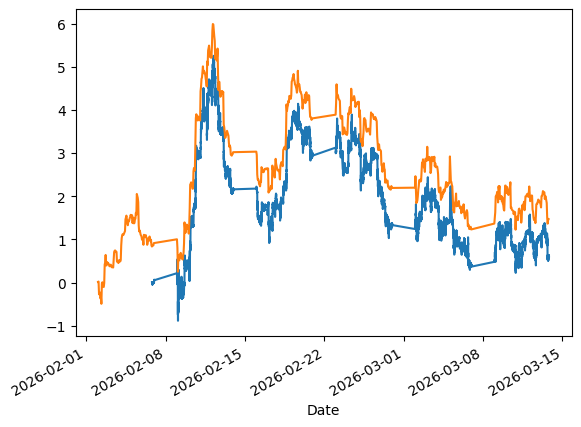

In [383]:

dlr = dollayenrlsd.copy()
dlr['signed_vol'] = dlr['volume'] * dlr['type'].map({0: 1, 1: -1})
dlr['ts'] = pd.to_datetime(dlr['date'], unit='s')
dlr = dlr.groupby('ts')[['signed_vol', 'profit','price']].sum()
dlr['signed_vol'] = dlr['signed_vol'].cumsum()
dlr['signed_vol'] =  dlr["signed_vol"].map(lambda x: f"{x:.6f}")
dlr['signed_vol'] = dlr['signed_vol'].astype(float)
dlr['traded_signal'] = dlr['signed_vol']#
#dlr
yen_full = get_usdjpy_signal()['2026-02-01':]
yen2 = yen_full.copy()
yen2['signal'] = yen2['signal'].shift()#.fillna(0)
yen2 = yen2[['signal','close']]

fullyen_data = mtw.get_tick_data("USDJPY",periodicity='1m',timeframe=  36000,end_dt = datetime.datetime.now()+datetime.timedelta(hours=9))
fullyen_data = fullyen_data[['close']]
fullyen_data.columns = ['close2']
#fullyen_data
yen3 = pd.concat([fullyen_data,yen2],axis = 1)
yen3["signal_minute"] = yen2['signal'].ffill()#inplace = True)
#yen3['signal']

#yen_c = pd.concat([yen2,yen3],axis = 1)#.ffill()
#yen_c['signal'].plot()
pnl = yen3['signal_minute'].ffill()*yen3['close2'].diff()
pnl2 = yen2['signal'].ffill()*yen2['close'].diff()
pnl.columns = ['pnlminute']
pnl2.columns = ['pnlhour']
pnl.cumsum().plot()
pnl2.cumsum().plot()

temp = combined[['signed_vol','signal']]#.plot(figsize = (20,10))
#temp = (temp - temp.mean()) / temp.std()
#temp = temp.loc["2026-02-05"]#.plot(figsize = (20,10))
temp = temp.loc["2026-02-05":]
idx  = pd.date_range(temp.index[0], temp.index[-1], freq='1min')
temp = temp.reindex(idx).ffill()
temp.plot()dd

In [384]:
yen_full = get_usdjpy_signal()
yen2 = yen_full.copy()
yen2[['close']]

,close
Date,
2022-05-04 20:00:00,130.004
2022-05-04 21:00:00,128.783
2022-05-04 22:00:00,129.135
2022-05-04 23:00:00,129.052
2022-05-05 00:00:00,129.156
...,...
2026-03-13 15:00:00,159.334
2026-03-13 16:00:00,159.103
2026-03-13 17:00:00,159.370


<Axes: >

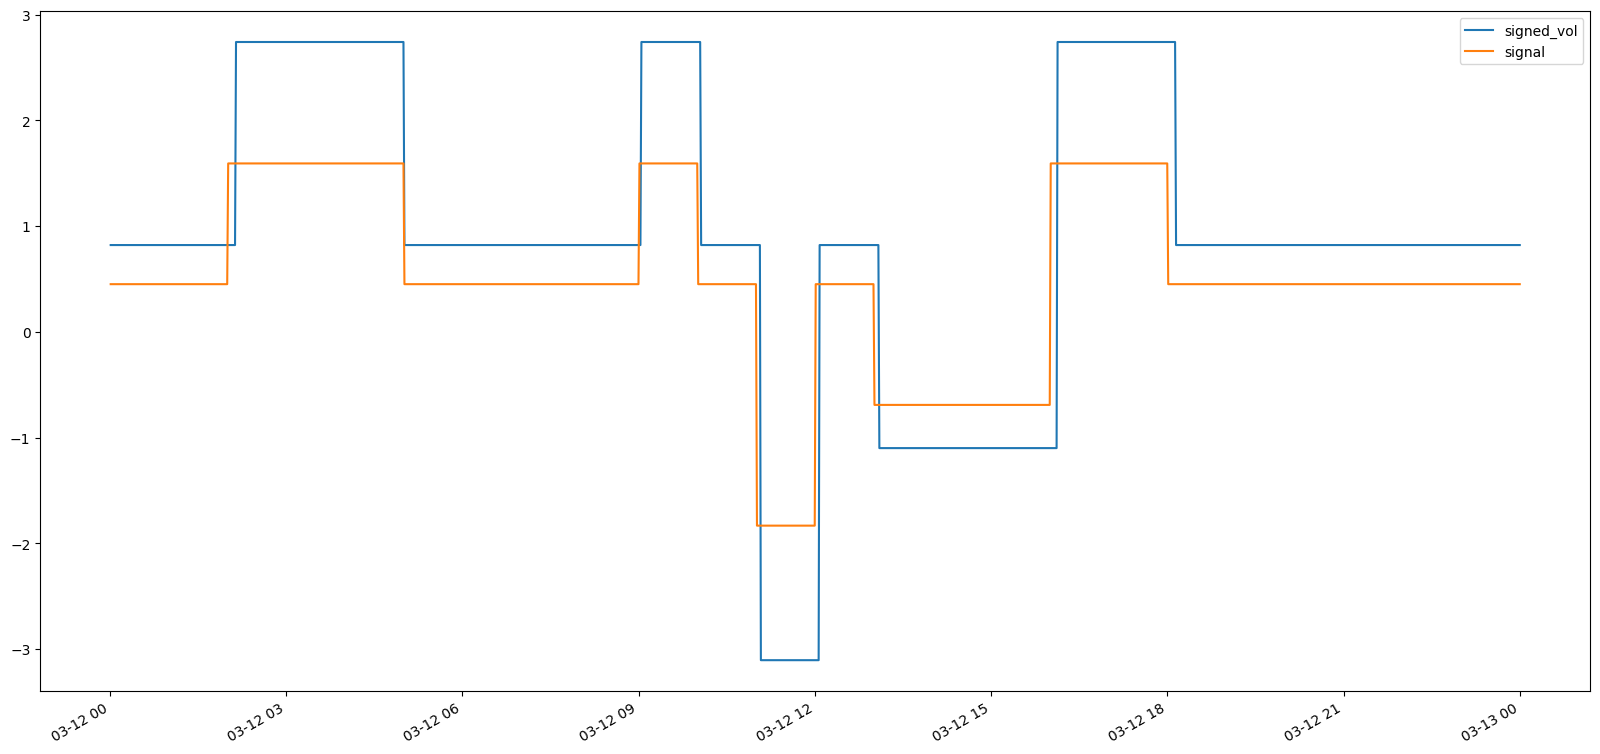

In [385]:

dlr = dollayenrlsd.copy()
dlr['signed_vol'] = dlr['volume'] * dlr['type'].map({0: 1, 1: -1})
dlr['ts'] = pd.to_datetime(dlr['date'], unit='s')
dlr = dlr.groupby('ts')[['signed_vol', 'profit','price']].sum()
dlr['signed_vol'] = dlr['signed_vol'].cumsum()
dlr['signed_vol'] =  dlr["signed_vol"].map(lambda x: f"{x:.6f}")
dlr['signed_vol'] = dlr['signed_vol'].astype(float)
dlr['traded_signal'] = dlr['signed_vol']#
#dlr
yen_full = get_usdjpy_signal()
yen2 = yen_full.copy()
yen2['signal'] = yen2['signal'].shift()#.fillna(0)
yen2 = yen2[['signal','close']]
combined = pd.concat([dlr, yen2], axis=1, join='outer').sort_index().ffill().dropna()

combined['signalchg'] = combined['signed_vol'].diff()
combined['dir_chg'] = [1 if s != 0  else 0 for s in combined['signalchg']]
#combined.corr()

is_hour    = (combined.index.minute == 0) & (combined.index.second == 0)
has_trade  = combined['dir_chg'] != 0

#combined = combined[is_hour | has_trade]

temp = combined[['signed_vol','signal']]#.plot(figsize = (20,10))
temp = (temp - temp.mean()) / temp.std()
idx = pd.date_range(start = temp.index.min(), end = temp.index.max(), freq = '1min')
temp = temp.reindex(idx, method = 'ffill')
temp
temp.loc["2026-03-12"].plot(figsize = (20,10))

<Axes: >

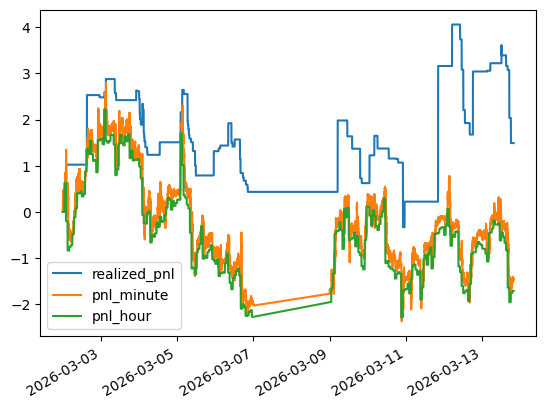

In [386]:
rlsd_pnl =dlr[['profit']]
rlsd_pnl.index = pd.to_datetime(rlsd_pnl.index)
#test_pnl = yen2['signal']*yen2['close'].diff()#.plot()
#test_pnl2 = yen3['signal']*yen3['close'].diff()#.plot()
#test_pnl.index = pd.to_datetime(test_pnl.index)
#test_pnl2.index = pd.to_datetime(test_pnl2.index)
full_df = pd.concat([rlsd_pnl, pnl,pnl2], axis=1).fillna(0)#.dropna()
full_df.columns = ['realized_pnl','pnl_minute','pnl_hour']
full_df = full_df["2026-03-01":].cumsum()#.plot()
full_df = (full_df - full_df.mean()) / full_df.std()
full_df.diff().fillna(0).cumsum().plot()

In [387]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import yfinance as yf

from saber import metaLib as mtlib
from saber import PyFolio as pf
from saber import utilities as ut
from saber import mailer as mail

from saber import metaData as mtd
from saber import riskEngine as risk
from saber import PcEngine as pe
from saber import implementationEngine as ie
from saber import PyFolio as pyf
from saber import PerformanceAnalytics as pa
import os

import mt5plalib as plalb

mtw = mtlib.meta5_wrapper(login = 7933713,pw = '1523@Rocket')
PerfA = pa.PA(mtw)
rkm = risk.riskMgr(mtw)
mtd.data(mtw).update_tick_data()
mtd.data(mtw).update_trade_sized_close()
strat_name = 'Discretionary Macro'
plalb.update_floating_pnl(PerfA,r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\discretionary_macro\floating_pnl")
plalb.update_realized_pnl(PerfA,r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\discretionary_macro\realized_pnl")
plalb.update_portfolio_var(rkm,r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\discretionary_macro\var")
pnl_df_dm = plalb.build_pnl_from_files(r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\discretionary_macro")
var_ts_dm = -plalb.build_var_timeseries(r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\discretionary_macro\var")
#plalb.send_acc_summary_email(pnl_df_dm, var_ts_dm, mtw, 'kmavyrle@gmail.com',strategy_name=strat_name)

print(var_ts_dm)


# Usage:
mtw = mtlib.meta5_wrapper()
PerfA = pa.PA(mtw)
rkm = risk.riskMgr(mtw)
strat_name = 'Systematic'
plalb.update_floating_pnl(PerfA,r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\systematic\floating_pnl")
plalb.update_realized_pnl(PerfA,r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\systematic\realized_pnl")
plalb.update_portfolio_var(rkm,r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\systematic\var",wdw = 20)
pnl_df_sys = plalb.build_pnl_from_files(r'C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\systematic')
var_ts_sys = plalb.build_var_timeseries(r'C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\systematic\var')
#plalb.send_acc_summary_email(pnl_df_sys, var_ts_sys, mtw, 'kmavyrle@gmail.com', strategy_name=strat_name)

VIX_F6  download failed
VIX_G6  download failed
VIX_J6  download failed
VIX_K6  download failed
VIX_M6  download failed
VIX_N6  download failed
VIX_Q6  download failed
VIX_U6  download failed
VIX_V6  download failed
VIX_X6  download failed
VIX_Z6  download failed
UST30Y_H6  download failed
Saved: floating_pnl_2026-03-14.csv
Error on 2026-01-01: "None of [Index(['2026-01-01'], dtype='object', name='Date')] are in the [index]" - skipping
Error on 2026-01-02: "None of [Index(['2026-01-02'], dtype='object', name='Date')] are in the [index]" - skipping
Error on 2026-01-03: "None of [Index(['2026-01-03'], dtype='object', name='Date')] are in the [index]" - skipping
Error on 2026-01-04: "None of [Index(['2026-01-04'], dtype='object', name='Date')] are in the [index]" - skipping
Error on 2026-01-05: "None of [Index(['2026-01-05'], dtype='object', name='Date')] are in the [index]" - skipping
Error on 2026-01-06: "None of [Index(['2026-01-06'], dtype='object', name='Date')] are in the [index]" -

<Axes: xlabel='Date'>

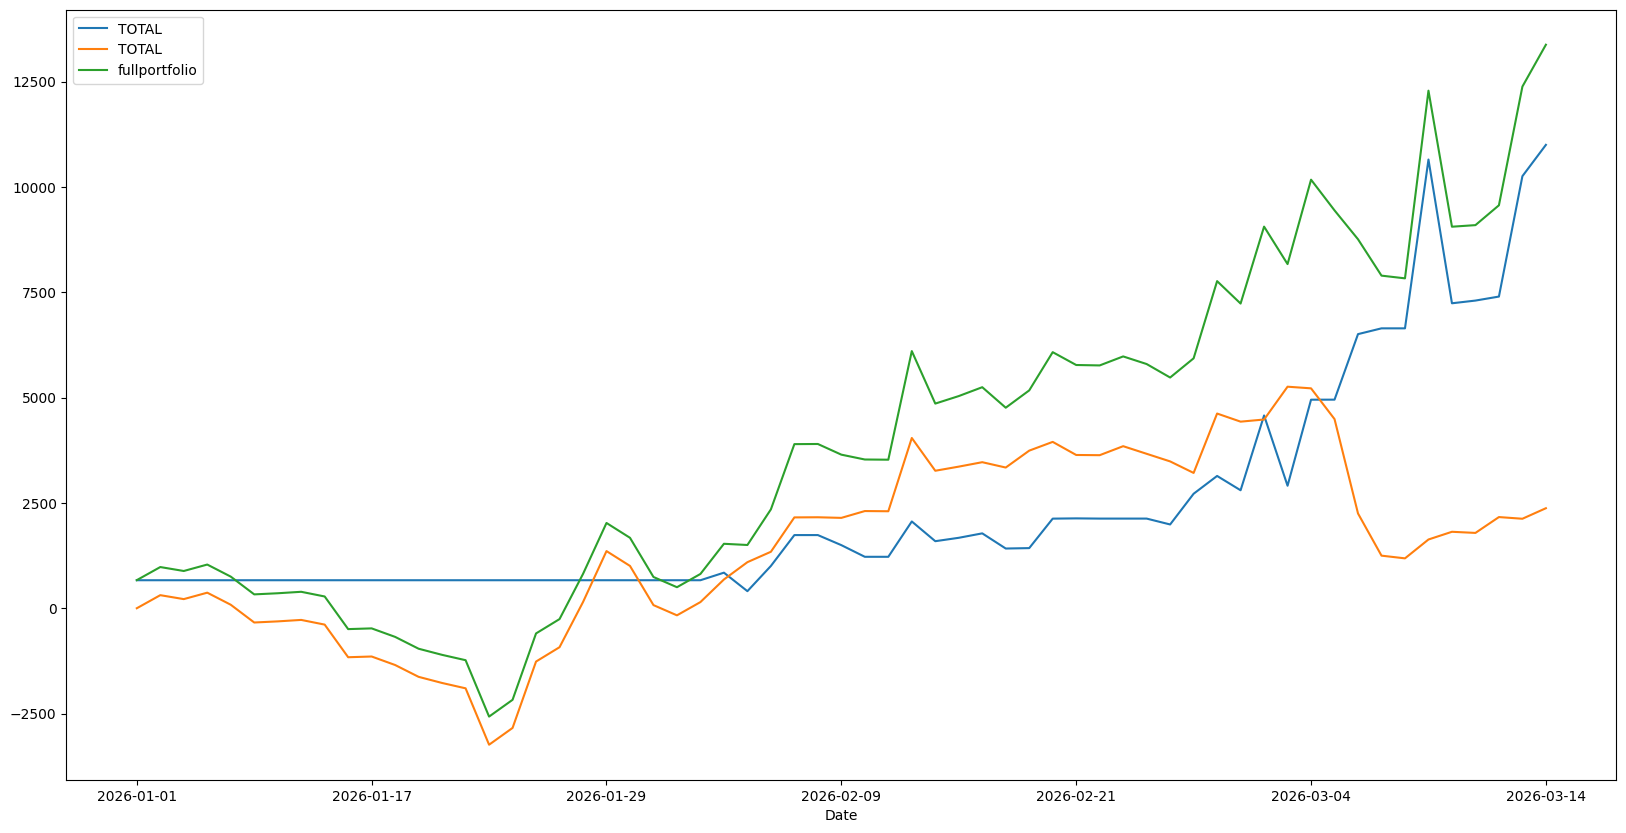

In [388]:
dff = pd.concat([pnl_df_dm[['TOTAL']],pnl_df_sys[['TOTAL']]],axis = 1)#.plot(figsize = (20,10))
dff = dff.sort_index().ffill().bfill()
dff['fullportfolio'] = dff.sum(axis = 1)
dff.plot(figsize = (20,10))

In [ ]:
def get_earnings_call_list(ticker: str) -> pd.DataFrame:
    api_key = "470f87cb037d4ca0b77042faf1b12c09"
    url = f"https://api.roic.ai/v2/company/earnings-calls/list/{ticker}?apikey={api_key}"
    
    r = requests.get(url)
    data = r.json()
    
    if not data or isinstance(data, dict):
        print(f"[SKIP] {ticker} — no earnings call data")
        return pd.DataFrame()
    
    df = pd.DataFrame(data)
    df['date'] = pd.to_datetime(df['date'], format='mixed', utc=True).dt.tz_localize(None)
    df = df.sort_values('date', ascending=False).reset_index(drop=True)
    return df

def get_earnings_call_transcript(ticker: str, year: int, quarter: int,return_type = 'transcript_only') -> str:
    api_key = "470f87cb037d4ca0b77042faf1b12c09"
    url = f"https://api.roic.ai/v2/company/earnings-calls/transcript/{ticker}?apikey={api_key}&year={year}&quarter={quarter}"
    
    r = requests.get(url)
    data = r.json()
    symbol = data['symbol']
    year = data['year']
    quarter = data['quarter']  
    release_dt = data['date']
    transcript = data['content']
    if return_type == 'transcript_only':
        return transcript
    else:
        return symbol,year,quarter,release_dt,transcript

def get_all_earnings_transcripts(ticker: str,start_year = None) -> pd.DataFrame:
    df = get_earnings_call_list(ticker)
    if df.empty:
        return df
    if start_year is not None:
        df = df[df['year']>=start_year]
    transcripts = []
    for _, row in df.iterrows():
        try:
            transcript = get_earnings_call_transcript(ticker, row['year'], row['quarter'])
            transcripts.append(transcript)
        except Exception as e:
            print(f"[FAIL] {ticker} Q{row['quarter']} {row['year']} — {e}")
            transcripts.append(None)
    
    df['transcript'] = transcripts
    return df


In [40]:
get_all_earnings_transcripts("CCJ")

,symbol,year,quarter,date,transcript
0,CCJ,2025,4,2026-02-13 00:00:00,Operator: Thank you for standing by. This is t...
1,CCJ,2025,3,2025-11-05 08:00:00,Operator: Thank you for standing by. This is t...
2,CCJ,2025,2,2025-07-31 08:00:00,Operator: Thank you for standing by. This is t...
3,CCJ,2025,1,2025-05-01 08:00:00,Operator: Thank you for standing by. This is t...
4,CCJ,2024,4,2025-02-20 08:00:00,Operator: Thank you for standing by. This is t...
...,...,...,...,...,...
63,CCJ,2007,3,2007-10-31 13:00:00,"Executives: Bob Lillie - Director, Investor Re..."
64,CCJ,2007,2,2007-07-30 15:00:00,TRANSCRIPT SPONSOR :\nExecutives: Bob Lillie -...
65,CCJ,2007,1,2007-04-30 12:00:00,\nExecutives
66,CCJ,2006,4,2007-02-07 10:00:00,TRANSCRIPT SPONSOR :\nExecutives: Bob Lillie -...


In [27]:
get_earnings_call_list('CCJ')

,symbol,year,quarter,date
0,CCJ,2025,4,2026-02-13 00:00:00
1,CCJ,2025,3,2025-11-05 08:00:00
2,CCJ,2025,2,2025-07-31 08:00:00
3,CCJ,2025,1,2025-05-01 08:00:00
4,CCJ,2024,4,2025-02-20 08:00:00
...,...,...,...,...
63,CCJ,2007,3,2007-10-31 13:00:00
64,CCJ,2007,2,2007-07-30 15:00:00
65,CCJ,2007,1,2007-04-30 12:00:00
66,CCJ,2006,4,2007-02-07 10:00:00


In [16]:
get_equity_fundamental_data('CCJ',start_dt = "2000-01-01",statement = 'income-statement')

<Response [403]>

In [13]:
get_multi_equity_fundamental_data(['CCJ'],start_dt = "2000-01-01",statement = 'all')

CCJ  — no data returned, skipping


""


In [ ]:
import requests
import pandas as pd
import numpy as np
import os

from functools import reduce

from saber import DataMgmt as dmgmt
from saber import fundEQ_lib as f_eq

dm = dmgmt.DataLake()
cn_eq_tkrs = ['1398.HK',"0939.HK","1288.HK","0857.HK","0386.HK","1088.HK","600519.SS","0941.HK","TCEHY","9988.HK","1211.HK","300750.SZ"]
us_eq_tkrs = ['AAPL','MSFT',"JPM","GOOG","NVDA","GS","XOM","CVX","JNJ","UNH","V","WMT","CAT","AMD","AMZN"]
in_eq_tkrs = ["RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","SBIN.NS","LT.NS","ULTRACEMCO.NS","NTPC.NS", "BHARTIARTL.NS","ITC.NS","HINDUNILVR.NS", "MARUTI.NS", "TATAMOTORS.NS","SUNPHARMA.NS", "ADANIPORTS.NS"]
kr_eq_tkrs = ["005930.KS","000660.KS",  "373220.KS","010950.KS", "051910.KS", "005380.KS",  "000270.KS", "005490.KS",  "035420.KS", "035720.KS", "329180.KS", "010140.KS",  "105560.KS",  "055550.KS", "207940.KS"]
eu_eq_tkrs = ["ASML.AS","SAP.DE", "TTE.PA","SIE.DE", "ALV.DE",  "BNP.PA",  "AIR.PA", "SAN.PA", "VOW3.DE", "ABI.BR", "IBE.MC","SAN.MC",  "ENI.MI",    "ISP.MI","SHEL.L" ]
uranium_producers = [
    "CCJ",      # Cameco
    "KAP.L",    # Kazatomprom (London)
    "UEC",      # Uranium Energy Corp
    "UUUU",     # Energy Fuels
    "URG",      # Ur-Energy
    "EU",       # enCore Energy
    "PDN.AX",   # Paladin Energy
    "BOE.AX",   # Boss Energy
    "PEN.AX",   # Peninsula Energy
    "LOT.AX",   # Lotus Resources
    "BMN.AX",   # Bannerman Energy
    "DYL.AX",   # Deep Yellow
    "GLO.TO",   # Global Atomic
    "CGNMF",    # CGN Mining
    "RIO",
    "BHP",
    "GXU.V",    # GoviEx
    "1164.HK",  # CGN Mining
    "DNN",
]
mk_custom_eq = ['CHA',"FLY","LKNCY","ENPH"]

uranium_eq = f_eq.get_multi_equity_fundamental_data(uranium_producers,start_dt = "2000-01-01",statement = 'all')

mk_custom_eq = f_eq.get_multi_equity_fundamental_data(mk_custom_eq,start_dt = "2000-01-01",statement = 'all')
dm.save_data('raw','fundamental','equities',uranium_eq,'uranium_producers_full_acc_data.csv',['date','ticker'])
dm.save_data('raw','fundamental','equities',mk_custom_eq,'mk_custom_full_acc_data.csv',['date','ticker'])

CCJ  failed to fetch data
KAP.L  failed to fetch data
UEC  failed to fetch data
UUUU  failed to fetch data
URG  failed to fetch data
EU  failed to fetch data
PDN.AX  failed to fetch data
BOE.AX  failed to fetch data
PEN.AX  failed to fetch data
LOT.AX  failed to fetch data
BMN.AX  failed to fetch data
DYL.AX  failed to fetch data
GLO.TO  failed to fetch data
CGNMF  failed to fetch data
RIO  failed to fetch data
BHP  failed to fetch data
GXU.V  failed to fetch data
1164.HK  failed to fetch data
DNN  failed to fetch data


ValueError: No objects to concatenate